In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
df = pd.read_csv("Dataset .csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [10]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [13]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [14]:
# Group by city and calculate average cost
df.groupby("City")["Average Cost for two"].mean()

City
Abu Dhabi           182.000000
Agra               1065.000000
Ahmedabad           857.142857
Albany               19.750000
Allahabad           517.500000
                      ...     
Weirton              25.000000
Wellington City      71.250000
Winchester Bay       25.000000
Yorkton              25.000000
��stanbul            81.428571
Name: Average Cost for two, Length: 141, dtype: float64

In [15]:
df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False)

City
Jakarta           308437.500000
Tangerang         250000.000000
Bogor             160000.000000
Bandung           150000.000000
Pasay City          3333.333333
                      ...      
Lakeview              10.000000
Lakes Entrance         7.000000
Inverloch              7.000000
Dicky Beach            7.000000
Miller                 0.000000
Name: Average Cost for two, Length: 141, dtype: float64

In [16]:
df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False).head()

City
Jakarta       308437.500000
Tangerang     250000.000000
Bogor         160000.000000
Bandung       150000.000000
Pasay City      3333.333333
Name: Average Cost for two, dtype: float64

<Axes: xlabel='City'>

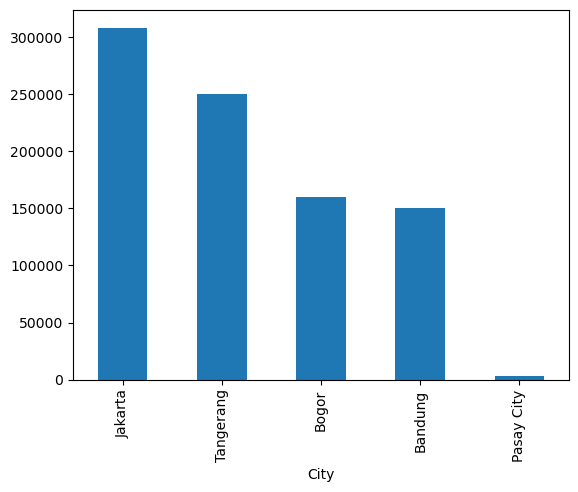

In [17]:

df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False).head().plot(kind='bar')

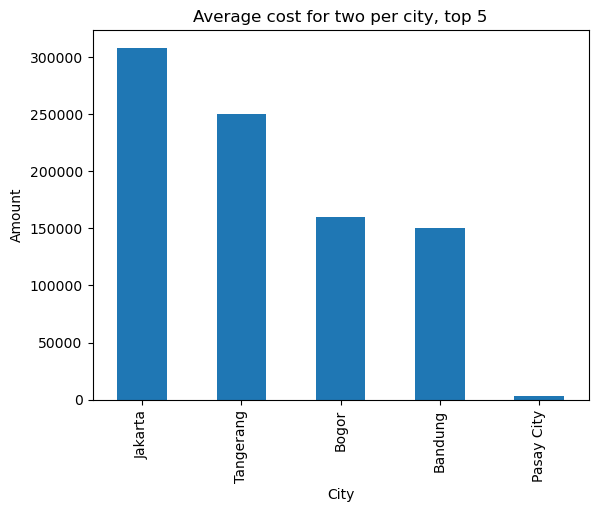

In [18]:
df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False).head().plot(kind='bar')
plt.title("Average cost for two per city, top 5")
plt.xlabel("City")
plt.ylabel("Amount")
plt.show()

In [19]:
#Cuisisnes, total number of votes

In [20]:
df.groupby("Cuisines")["Votes"].sum()

Cuisines
Afghani                                        39
Afghani, Mughlai, Chinese                       2
Afghani, North Indian                           0
Afghani, North Indian, Pakistani, Arabian       3
African                                       373
                                             ... 
Western, Asian, Cafe                          259
Western, Fusion, Fast Food                     32
World Cuisine                                  95
World Cuisine, Mexican, Italian               115
World Cuisine, Patisserie, Cafe              1034
Name: Votes, Length: 1825, dtype: int64

In [21]:
data = df.groupby("Cuisines")["Votes"].sum().reset_index()

In [22]:
data

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
2,"Afghani, North Indian",0
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
...,...,...
1820,"Western, Asian, Cafe",259
1821,"Western, Fusion, Fast Food",32
1822,World Cuisine,95
1823,"World Cuisine, Mexican, Italian",115


In [23]:
data[data["Votes"] == 0]

,Cuisines,Votes
2,"Afghani, North Indian",0
164,"Awadhi, Mughlai",0
185,"Bakery, Chinese, North Indian",0
193,"Bakery, Desserts, Fast Food, Mithai",0
208,"Bakery, Healthy Food",0
213,"Bakery, North Indian",0
214,"Bakery, Pizza",0
224,"Bengali, Chinese",0
234,"Beverages, Healthy Food",0
323,"Burger, Pizza, Fast Food",0


In [24]:
data[data["Votes"] != 0]

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
5,"African, Portuguese",265
...,...,...
1820,"Western, Asian, Cafe",259
1821,"Western, Fusion, Fast Food",32
1822,World Cuisine,95
1823,"World Cuisine, Mexican, Italian",115


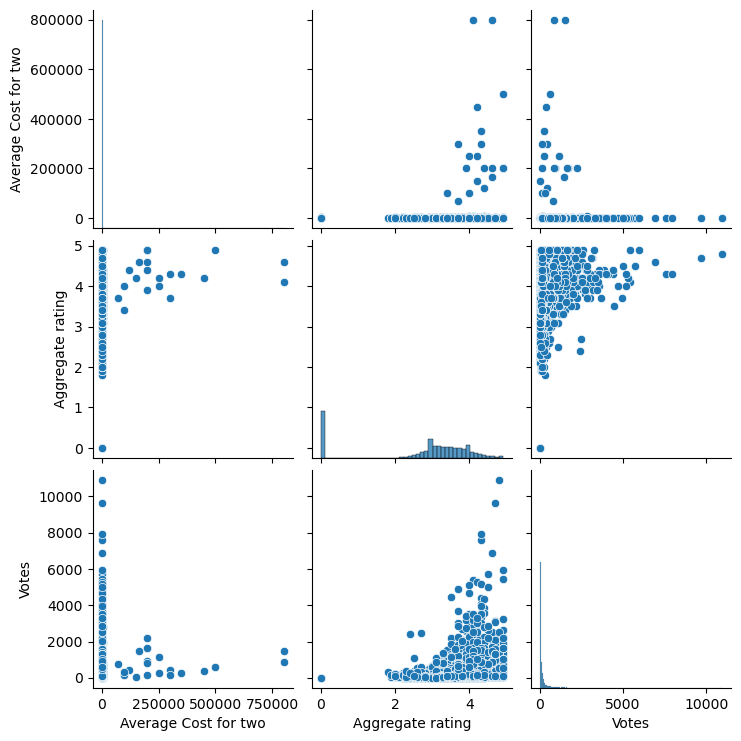

In [25]:
sns.pairplot(df[["Average Cost for two", "Aggregate rating", "Votes"]])

In [26]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [27]:
df["Has Online delivery"].value_counts()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

<Axes: ylabel='count'>

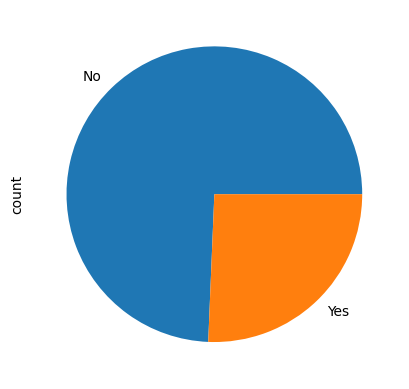

In [28]:
 df["Has Online delivery"].value_counts().plot(kind='pie')

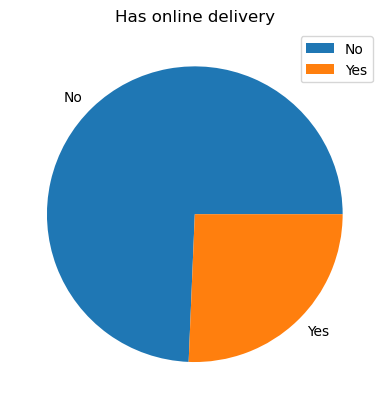

In [29]:
df["Has Online delivery"].value_counts().plot(kind='pie')
plt.title("Has online delivery")
plt.ylabel("")
plt.legend()
plt.show()


In [30]:
df["Rating text"].head()

0    Excellent
1    Excellent
2    Very Good
3    Excellent
4    Excellent
Name: Rating text, dtype: object

In [31]:
df[["Aggregate rating", "Rating text"]].head(10)

,Aggregate rating,Rating text
0,4.8,Excellent
1,4.5,Excellent
2,4.4,Very Good
3,4.9,Excellent
4,4.8,Excellent
5,4.4,Very Good
6,4.0,Very Good
7,4.2,Very Good
8,4.9,Excellent
9,4.8,Excellent


In [32]:
df[["Aggregate rating", "Rating text"]].sort_values(by="Aggregate rating", ascending=True).head(7000)

,Aggregate rating,Rating text
2204,0.0,Not rated
78,0.0,Not rated
77,0.0,Not rated
69,0.0,Not rated
6953,0.0,Not rated
...,...,...
9348,3.6,Good
36,3.6,Good
7017,3.6,Good
7019,3.6,Good


In [33]:
df[df["Rating text"] != "Not rated"]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [34]:
df = df [df["Rating text"] != "Not rated"]

In [35]:
df["Rating text"].value_counts()

Rating text
Average      3737
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

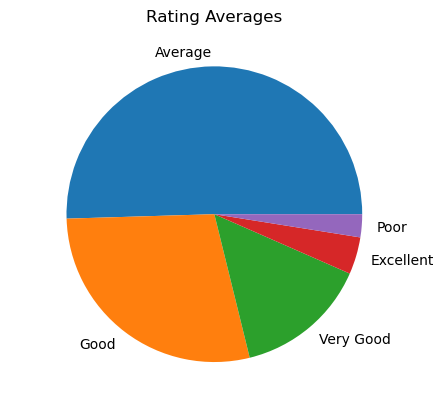

In [36]:
df["Rating text"].value_counts().plot(kind = "pie")
plt.title("Rating Averages")
plt.ylabel(" ")
plt.show()

In [37]:
#FEATURE ENGINEERING (MODELLING)

In [38]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [39]:
X = df[['Average Cost for two','Has Table booking','Has Online delivery', 'Price range']]

In [40]:
#AGGREGATE RATING
#Above 2 below 2.5  Poor
#Above 2.5 below 3.5  Average 
#Above 3.5 below 4.0  Good
#Above 4.0 below 4.5  Very Good
#Above 4.5  Excellent 

In [41]:
y = df[["Aggregate rating"]]

In [42]:
X

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,Yes,No,3
1,1200,Yes,No,3
2,4000,Yes,No,4
3,1500,No,No,4
4,1500,Yes,No,4
...,...,...,...,...
9546,80,No,No,3
9547,105,No,No,3
9548,170,No,No,4
9549,120,No,No,4


In [43]:
X["Price range"].value_counts()

Price range
1    2744
2    2711
3    1373
4     575
Name: count, dtype: int64

In [44]:
from sklearn import preprocessing 
labelencoder = preprocessing.LabelEncoder()

In [45]:
X["Has Table booking"] = labelencoder.fit_transform(X["Has Table booking"])

C:\Users\Aayushi\AppData\Local\Temp\ipykernel_17308\3860357707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Has Table booking"] = labelencoder.fit_transform(X["Has Table booking"])


In [46]:
X

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,No,3
1,1200,1,No,3
2,4000,1,No,4
3,1500,0,No,4
4,1500,1,No,4
...,...,...,...,...
9546,80,0,No,3
9547,105,0,No,3
9548,170,0,No,4
9549,120,0,No,4


In [47]:
 #Has Table booking 0 is no and 1 is yes 

In [48]:
labelencoder.classes_

array(['No', 'Yes'], dtype=object)

In [49]:
X["Has Online delivery"] = labelencoder.fit_transform(X["Has Online delivery"])

C:\Users\Aayushi\AppData\Local\Temp\ipykernel_17308\3223307020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Has Online delivery"] = labelencoder.fit_transform(X["Has Online delivery"])


In [50]:
X

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,0,3
1,1200,1,0,3
2,4000,1,0,4
3,1500,0,0,4
4,1500,1,0,4
...,...,...,...,...
9546,80,0,0,3
9547,105,0,0,3
9548,170,0,0,4
9549,120,0,0,4


In [51]:
labelencoder.classes_

array(['No', 'Yes'], dtype=object)

In [52]:
# Has Table booking 0 is no 1 is yes 
# Has Online delivery 0 is no 1 is yes 

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [55]:
X = scaler.fit_transform(X)

In [56]:
X

array([[-0.0190367 ,  2.37978283, -0.68302371,  1.10671644],
       [-0.0135729 ,  2.37978283, -0.68302371,  1.10671644],
       [ 0.13941344,  2.37978283, -0.68302371,  2.18135204],
       ...,
       [-0.06985002, -0.42020641, -0.68302371,  2.18135204],
       [-0.07258191, -0.42020641, -0.68302371,  2.18135204],
       [-0.07613338, -0.42020641, -0.68302371,  0.03208084]],
      shape=(7403, 4))

In [57]:
from sklearn.model_selection import  train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)